# Uplift Modeling Analysis

This notebook explores uplift modeling, a data science technique used to measure the incremental impact of a treatment or intervention on customer behavior. For example, in marketing, uplift modeling helps determine how much an advertisement increases the chance of a customer making a purchase compared to not seeing the ad.

We'll work with customer data from two groups:
- **Control group**: Customers who did not receive the treatment (e.g., no ad).
- **Treatment group**: Customers who received the treatment (e.g., saw an ad).

The goal is to build models that predict the uplift—the difference in response rates between treated and untreated customers—and identify which customers are most likely to respond positively to the treatment.

There's a clear distinction between using a propensity model and an uplift model. Propensity model do not account for treatment effects and predict overall response rate. Meanwhile, uplift models predict response rate **caused by** treatment. Compared to a propensity model, an uplift model can help us distinguish between four segments of customers:

<table>
  <thead>
    <tr>
      <th></th>
      <th>Untreated Low</th>
      <th>Untreated High</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>Treated Low</th>
      <td>Lost Cause</td>
      <td>Ignore</td>
    </tr>
    <tr>
      <th>Treated High</th>
      <td>Target</td>
      <td>Sure Thing</td>
    </tr>
  </tbody>
</table>


This allows us to direct marketing investments more strategically and compute more accurate ROME. More precisely, the Lost Cause and Ignore segments should not be targeted as that will yield a negligible or negative return. While the Sure Thing segment returns should not be attributed to marketing spend. 

We'll use Python libraries like Polars for data manipulation and pyrsm for statistical analysis and modeling.


## Loading the Data

To perform uplift analysis, we need data from both the control and treatment groups. These datasets contain customer information and their responses.

- The control group data represents customers who were not exposed to the treatment.
- The treatment group data represents customers who were exposed to the treatment.

We'll load these datasets using Polars, a fast data processing library, and examine their structure.

In [38]:
## loading the organic data - this dataset must NOT be changed
cg_organic_control = pl.read_parquet("data/cg_organic_control.parquet")
cg_organic_control.head()

converted,GameLevel,NumGameDays,NumGameDays4Plus,NumInGameMessagesSent,NumSpaceHeroBadges,NumFriendRequestIgnored,NumFriends,AcquiredSpaceship,AcquiredIonWeapon,TimesLostSpaceship,TimesKilled,TimesCaptain,TimesNavigator,PurchasedCoinPackSmall,PurchasedCoinPackLarge,NumAdsClicked,DaysUser,UserConsole,UserHasOldOS
cat,i32,i32,i32,i32,i32,i32,i32,cat,cat,i32,i32,i32,i32,cat,cat,i32,i32,cat,cat
"""no""",7,18,0,124,0,81,0,"""yes""","""no""",8,0,0,4,"""no""","""yes""",3,2101,"""no""","""no"""
"""no""",10,3,2,60,0,18,479,"""no""","""no""",10,7,0,0,"""yes""","""no""",7,1644,"""yes""","""no"""
"""no""",2,1,0,0,0,0,0,"""no""","""no""",0,0,0,2,"""no""","""no""",8,3197,"""yes""","""yes"""
"""no""",2,11,1,125,0,73,217,"""no""","""no""",0,0,0,0,"""yes""","""no""",6,913,"""no""","""no"""
"""no""",8,15,0,0,0,6,51,"""yes""","""no""",0,0,2,1,"""yes""","""no""",21,2009,"""yes""","""no"""


## Preparing the Data for Uplift Modeling

To build an uplift model, we need to combine the control and treatment data into one dataset. We'll add a binary variable called 'ad' (1 for treated, 0 for control) to indicate which group each customer belongs to. This setup allows machine learning models to learn the difference in responses between the groups.

First, we load an additional dataset and prepare the combined data.

In [ ]:
cg_ad_random = cg_ad_random.with_columns(pl.lit(1).alias("ad"))
cg_organic_control = cg_organic_control.with_columns(pl.lit(0).alias("ad"))

# Create a variable called 'cv1_yes' that has value 1 when conversion == 'yes', has value 0 when conversion == 'no'
cg_rct_stacked = cg_rct_stacked.with_columns(
    pl.when(pl.col("converted") == "yes")
    .then(1)
    .when(pl.col("converted") == "no")
    .then(0)
    .otherwise(None)
    .alias("cv1_yes")
)
cg_rct_stacked["cv1_yes"].value_counts(sort=False)

cv1_yes,count
i32,u32
1,5619
0,54381


## We will create our training and validation sets stratified over treatment and response to ensure balance

In [ ]:
cg_rct_stacked = cg_rct_stacked.with_columns(
    pl.Series(
        "training",
        rsm.model.make_train(
            data=cg_rct_stacked,
            test_size=0.3,
            strat_var=["converted", "ad"],
            random_state=1234,
        ),
    )
)

cg_rct_stacked.group_by("training").len().with_columns(
    (pl.col("len") / pl.col("len").sum()).round(2).alias("proportion")
)

training,len,proportion
i64,u32,f64
0,18000,0.3
1,42000,0.7


## Building Uplift Models

With the combined dataset ready, we can now train machine learning models to predict uplift. Uplift is the difference in the probability of a positive outcome (e.g., purchase) between treated and untreated customers.

We'll use various modeling techniques, including logistic regression and more advanced methods, to estimate the treatment effect. The models will help identify customers who are most likely to respond to the treatment.

In this step, we will skip some portions of the code used to train models to stay focused on uplift concepts

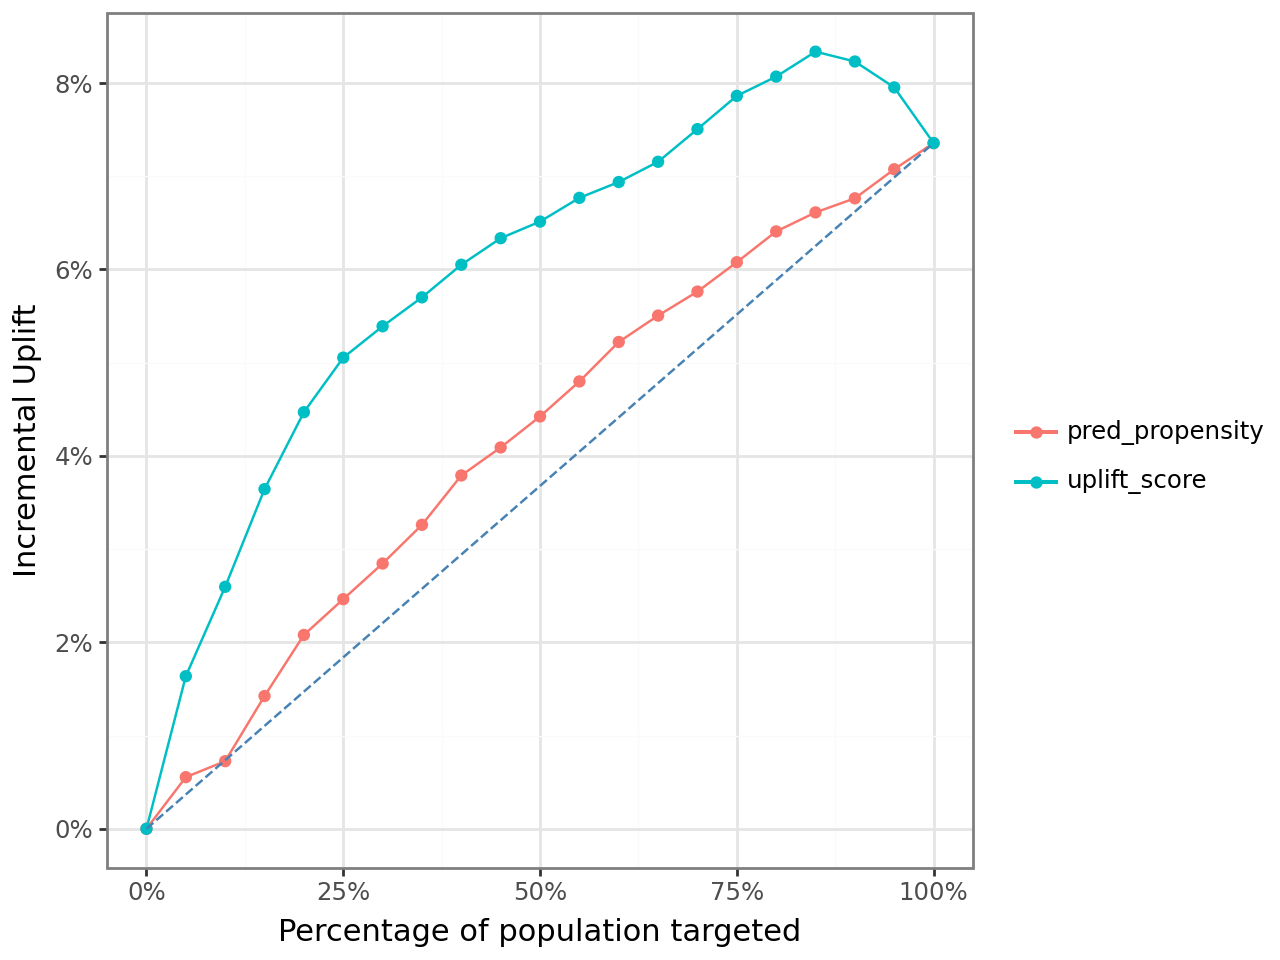

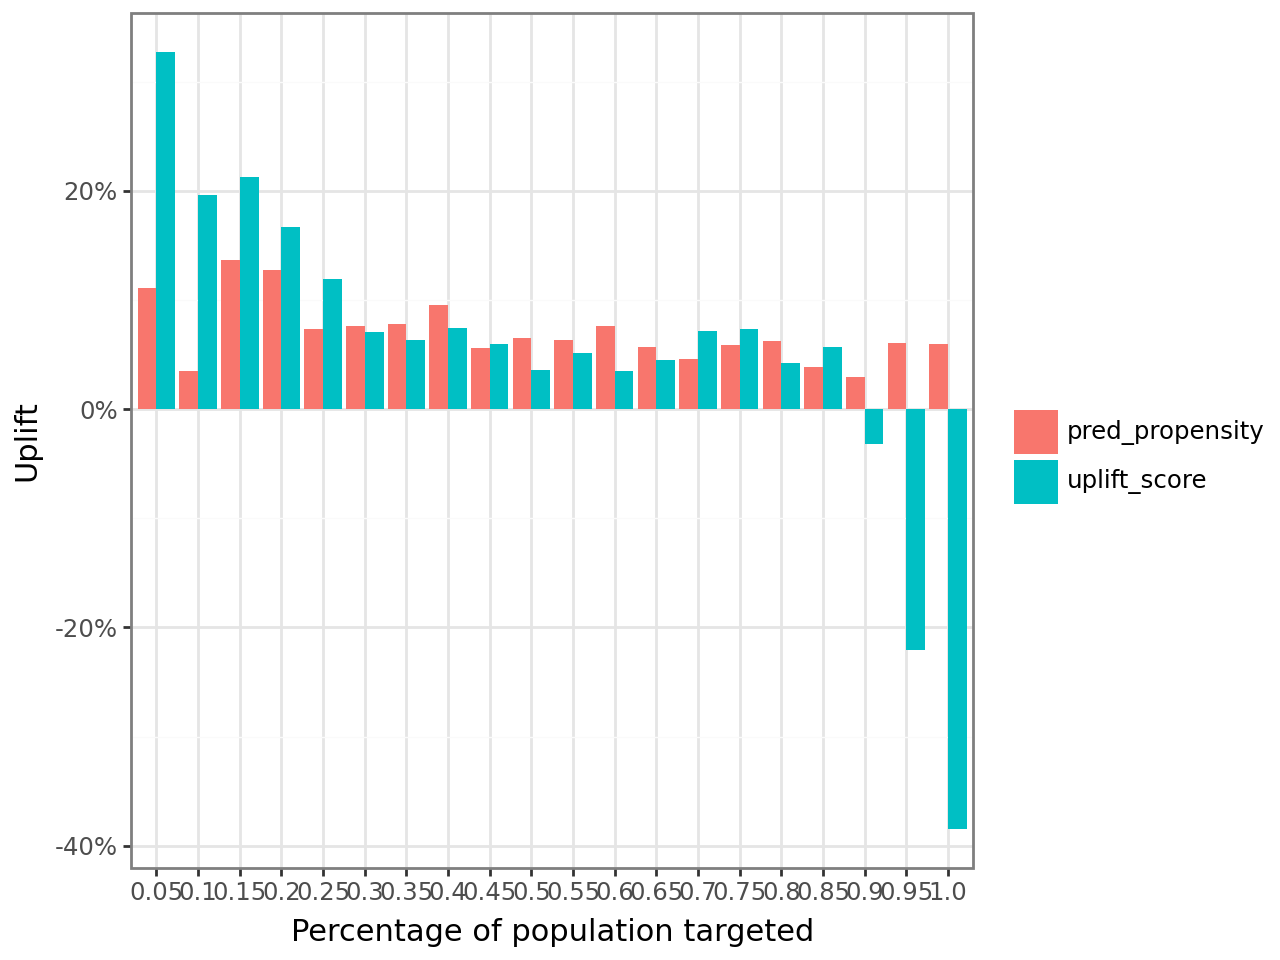

Expected incremental profit (uplift): 45907.75976154994
Expected incremental profit (propensity): -694.4477804681228


In [65]:
tab, tab_propen, df_master = analyze_uplift(clf_control, clf_treatment, clf_propensity)


## Evaluating Model Performance and Visualizing Results

After training the models, we evaluate their performance using metrics like accuracy, AUC, and uplift curves. We also create plots to visualize the predictions and the treatment effects.

This helps us understand how well the models distinguish between customers who will respond to the treatment and those who won't, and identify the most effective targeting strategies.

Plot 1: Cumulative Uplift (Logit Model)

The uplift model outperforms the propensity model by reaching 8% incremental uplift at 85% targeting. It shoots up quickly meaning we're finding customers who really need our ads to buy, and after 85% it starts falling because now we're targeting customers who buy less with ads. The propensity model climbs more slowly meaning it's finding customers who are more likely to buy, but many would have bought anyway. The gap in the plots indicates the uplift model is creating more value for every dollar spent.

Plot 2: Incremental Uplift by Bin (Logit Model)

This chart sorts customers into bins to show how much value each group creates. The top 25% of customers are responsive to our ads in our uplift model. The propensity model bars are smaller and overall flatter because it can't tell the difference between best and avg customers (it's just going based on the probability of buying). The uplift performs worse at the end because the last 15% of customers are less likely to buy if we advertise to them.

In [ ]:
uplift_complete(tab, tab_propen, df_master)


Breakeven threshold: 0.1001
Formula: Target customers where pred_treatment > 0.1001
Optimal percentage: 20%
Maximum profit: $1,404.90
Customers above threshold: 8,647
Percentage to target: 48.0%
Optimal percentage: 25%
Maximum profit: $45,907.76
Customers above threshold: 1,974
Percentage to target: 21.9%

Propensity model
Profit: $1,404.90

Uplift model
Profit: $45,907.76


## Nonlinear models (MLP)

We started with linear regression to serve as our baseline and provide insights into feature importance, relationships and correlation with response. Next we will train nonlinear models starting with simple MLP. Nonlinear models help us capture non-linear relationships we may have missed. The chosen features are refined based on our results from linear regression. Moreover, we will tune our models using cross validation to optimize **ROC AUC**


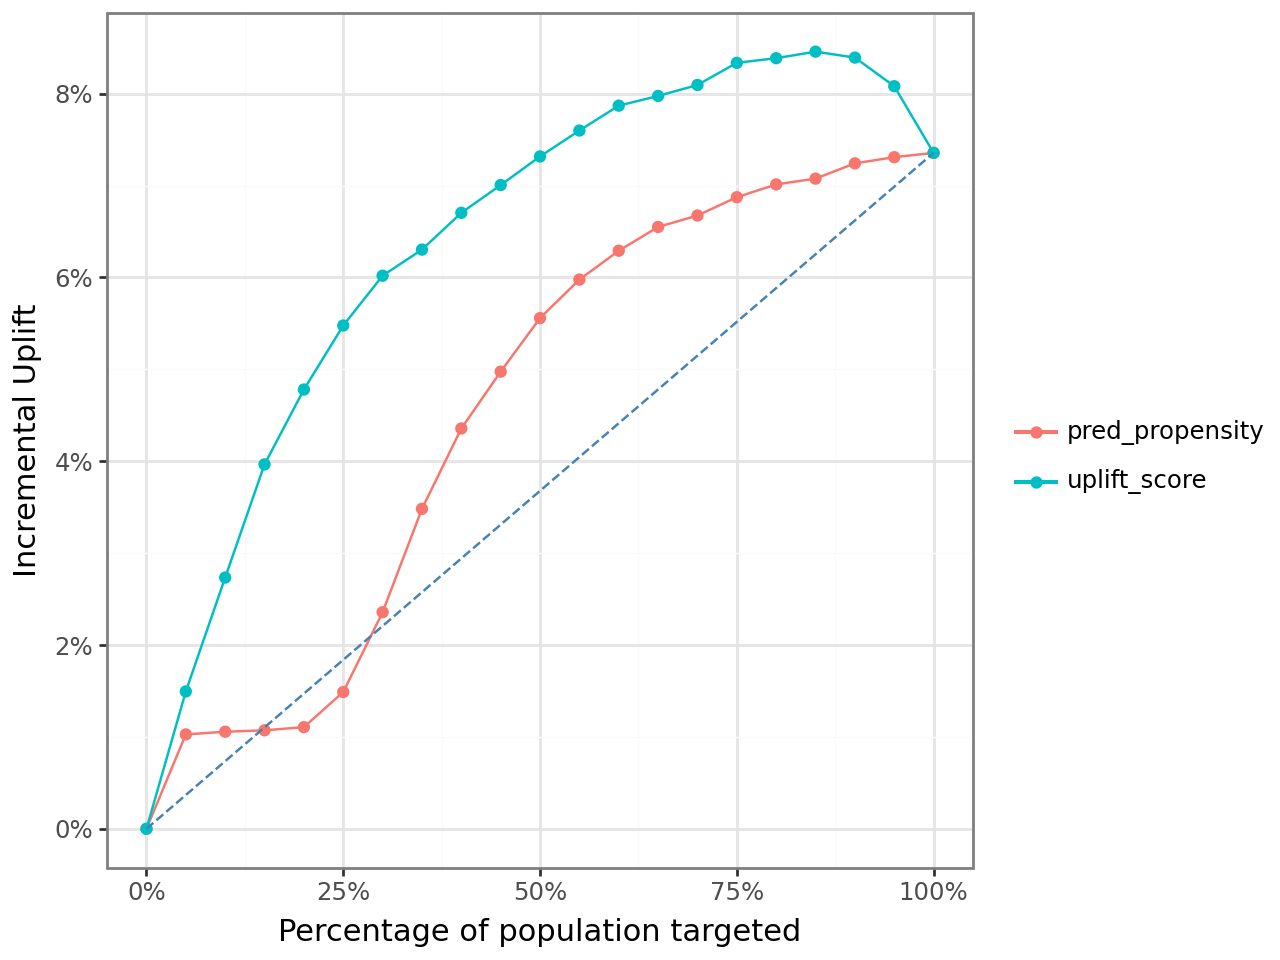

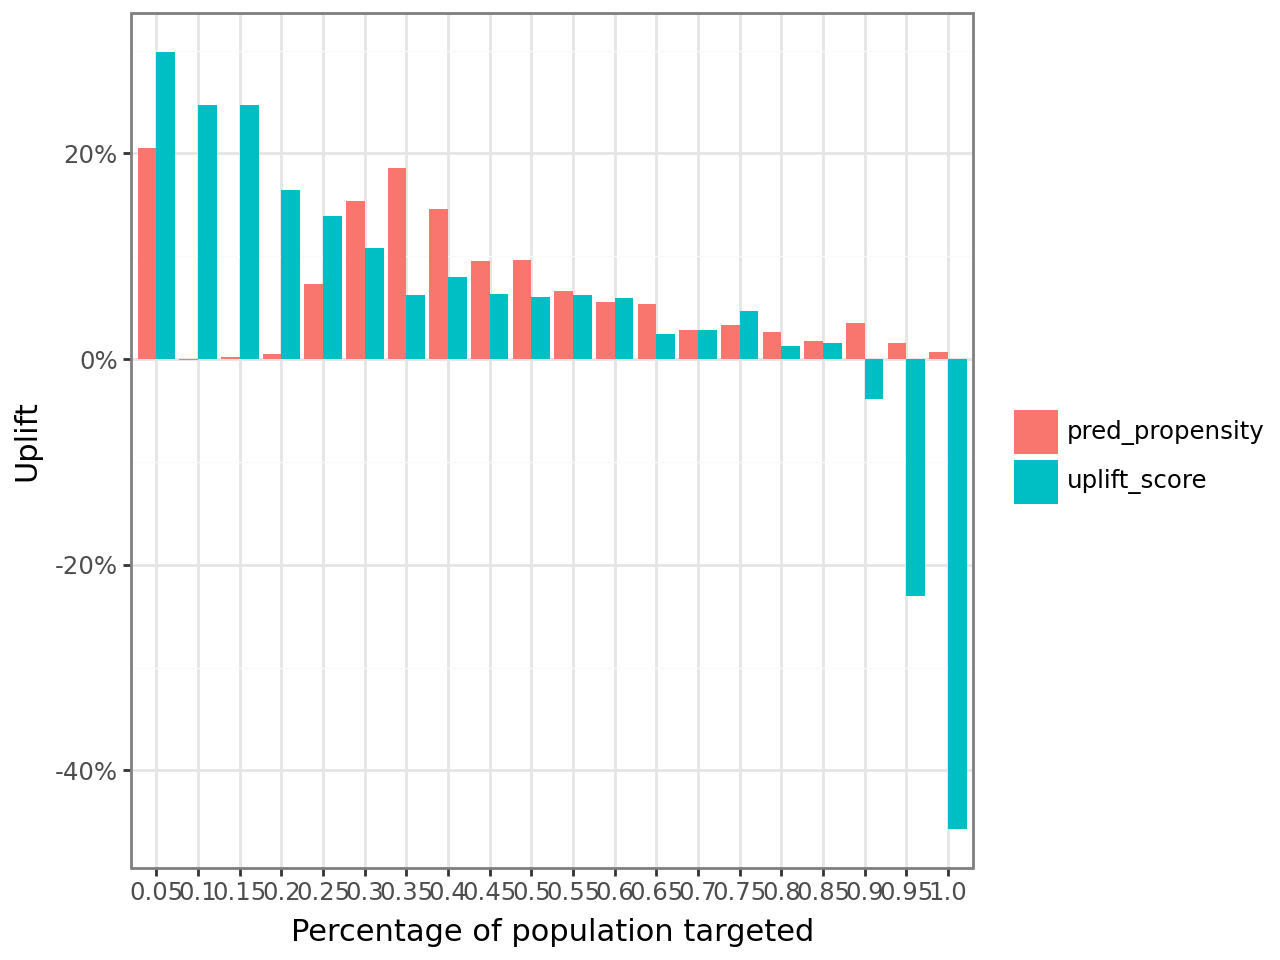

Expected incremental profit (uplift): 53521.38688147295
Expected incremental profit (propensity): -18225.063175122745


In [70]:
tab, tab_propen, df_master = analyze_uplift(
    mlp_control, mlp_treatment, mlp_propensity, ci=False
)


Plot 1: Cumulative Uplift (MLP Model)

The uplift model significantly outperforms the propensity model, reaching about 9% incremental uplift compared to propensity's 7.3%. The blue line climbs steeply at first, showing the MLP model is excellent at identifying customers who genuinely need ads to convert. The propensity model starts very flat—barely above random targeting (dotted line) for the first 30%—meaning it's wasting budget on customers who'd buy anyway. After 90% targeting, the uplift line drops sharply as we hit customers who are actively turned off by advertising. The much larger gap between blue and the diagonal shows the uplift approach creates far more value per marketing dollar spent.

Plot 2: Incremental Uplift by Bin (MLP Model)
Sorting customers into groups reveals dramatic differences. The uplift model shows massive performance in the first bin—nearly 30% uplift for the top 5% of customers. These are people who desperately need our ads to buy. The next few groups maintain strong 20-25% uplift. The propensity model has an unusual spike around bin 7 (around 35% targeting) showing it finds a pocket of likely buyers, but overall performs much more inconsistently. Most critically, the uplift model reveals the last two bins with -25% to -45% uplift—these customers find our ads so annoying they're less likely to buy. The propensity model stays slightly negative at the end but misses the severity of this problem, leading to massive profit loss of -$18,225 while uplift generates $53,521 profit.

In [ ]:
uplift_analysis(tab, tab_propen, df_master)


Breakeven threshold: 0.1001
Formula: Target customers where pred_treatment > 0.1001
Optimal percentage: 50%
Maximum profit: $9,976.15
Customers above threshold: 7,607
Percentage to target: 42.3%
Optimal percentage: 30%
Maximum profit: $54,270.05
Customers above threshold: 2,459
Percentage to target: 27.3%

Propensity model
Profit: $9,976.15

Uplift model
Profit: $54,270.05


## Nonlinear models (xgboost)

Next we will model our solution using boosted trees (xgboost)


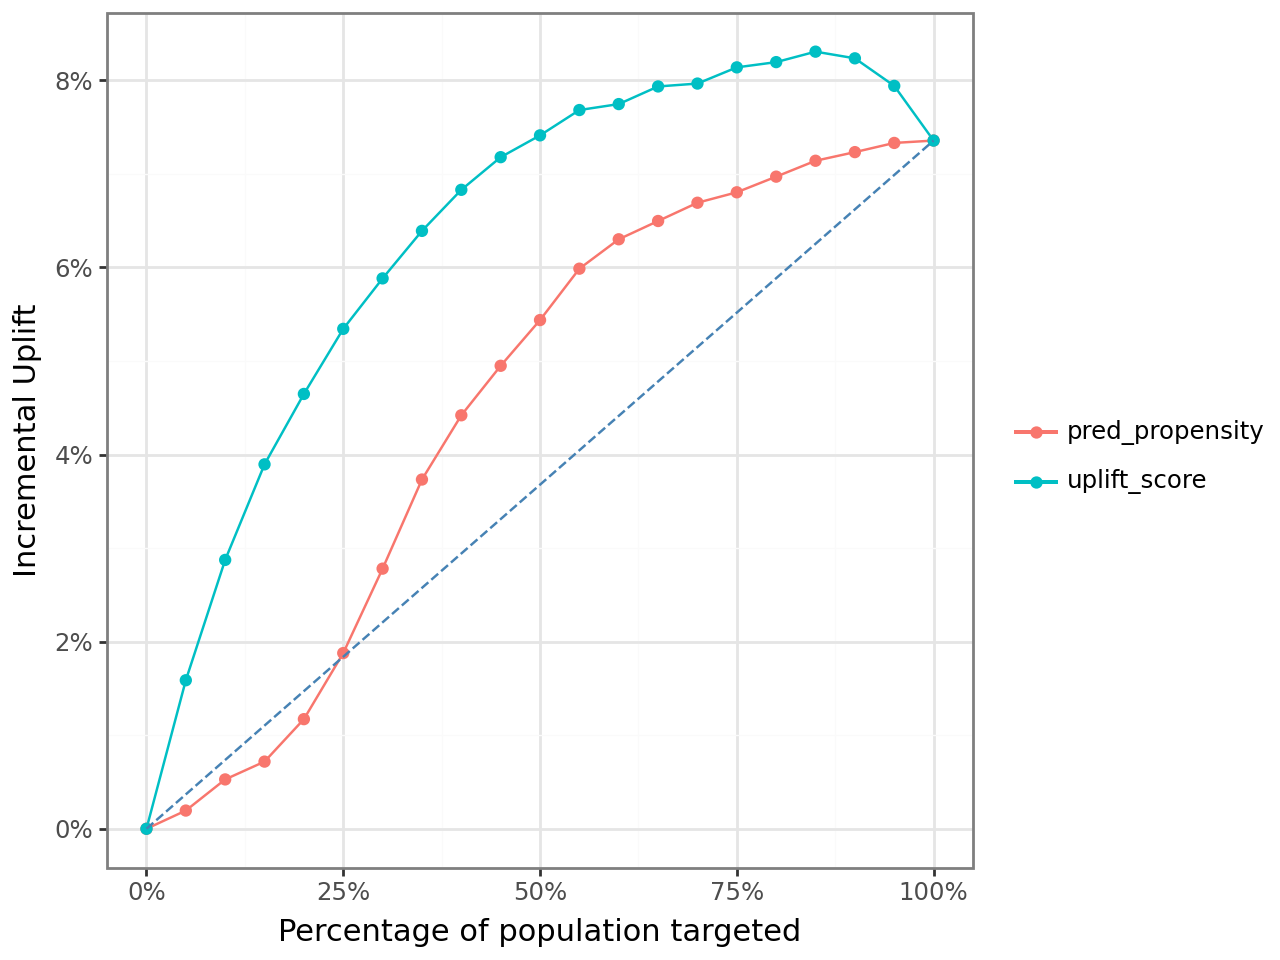

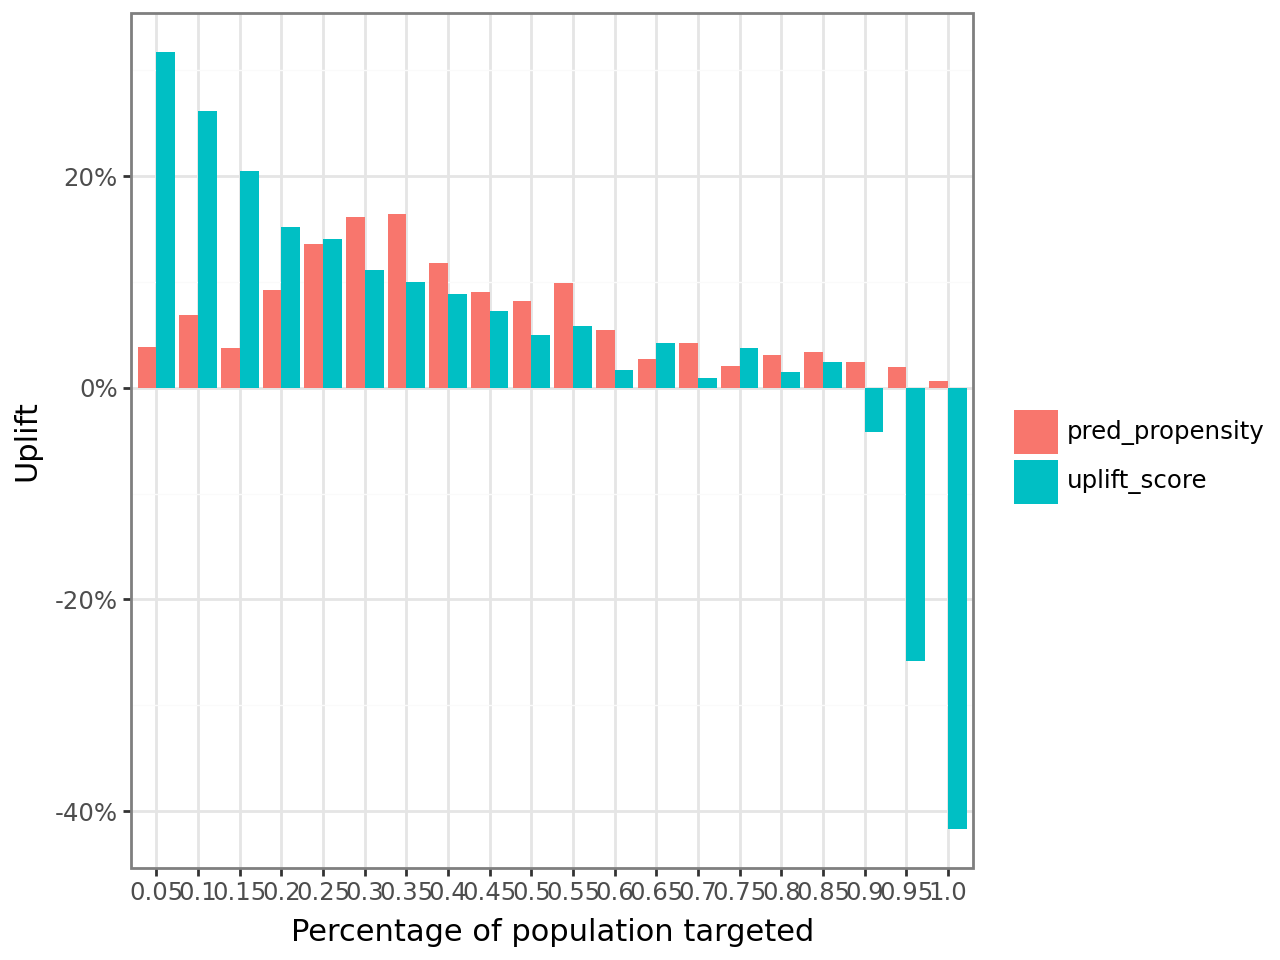

Expected incremental profit (uplift): 51110.03866766843
Expected incremental profit (propensity): -11220.531505886487


In [80]:
tab, tab_propen, df_master = analyze_uplift(
    xgb_control, xgb_treatment, xgb_prospen, ci=False
)


Plot 1: Cumulative Uplift (XGBoost Model)

The uplift model dramatically outperforms the propensity model, reaching about 8.3% incremental uplift at 90% targeting compared to propensity's 7.3%. The blue line rockets upward from the start, showing XGBoost excels at identifying customers who genuinely need ads to convert. The propensity model (red) starts extremely slowly—actually running below the random targeting line (dotted) for the first 15%—meaning it's actively performing worse than random selection by wasting budget on customers who'd buy anyway. After 90% targeting, the uplift curve drops as we hit customers who respond negatively to advertising. The dramatically larger area between the blue line and the diagonal shows the uplift approach creates far more incremental value per dollar spent.

Plot 2: Incremental Uplift by Bin (XGBoost Model)
This chart shows XGBoost's strong customer segmentation. The uplift model delivers exceptional performance in the first bin—over 27% uplift for the top 5% of customers who desperately need ads. The next three bins maintain robust 17-23% uplift. The propensity model shows weak and inconsistent performance across all bins, with its best performance oddly appearing in the middle bins (30-35%) at around 17-18%, suggesting it's confused about who the best customers actually are. Most critically, the uplift model reveals the last two bins with -28% to -43% uplift—customers so turned off by ads they're far less likely to buy. The propensity model stays slightly positive throughout, completely missing these problematic customers, which explains why it loses $11,221 in profit while uplift generates $51,110.

In [ ]:
uplift_analysis(tab, tab_propen, df_master)


Breakeven threshold: 0.1001
Formula: Target customers where pred_treatment > 0.1001
Optimal percentage: 55%
Maximum profit: $8,681.67
Customers above threshold: 7,863
Percentage to target: 43.7%
Optimal percentage: 35%
Maximum profit: $51,948.40
Customers above threshold: 2,565
Percentage to target: 28.5%

Propensity model
Profit: $8,681.67

Uplift model
Profit: $51,948.40


## Key Results

### Baseline Uplift Model
- Uplift model reaches about **8% incremental uplift at 85% targeting**.
- Propensity model grows slower and is less able to distinguish high-value, treatment-sensitive customers.
- The uplift model creates more value early and avoids wasting effort on customers who would have converted anyway.

### MLP Uplift Model
- Uplift outperforms propensity:
  - ~**9% uplift** vs **7.3%** for propensity.
- Top customers show very strong uplift:
  - nearly **30% uplift for the top 5%**.
- Last bins are strongly negative:
  - around **-25% to -45% uplift**, indicating customers harmed by advertising.
- Profit comparison:
  - uplift model generates **+$53,521**
  - propensity model loses **-$18,225**

### XGBoost Uplift Model
- Uplift also outperforms propensity:
  - ~**8.3% uplift** vs **7.3%** for propensity.
- Top 5% customers show:
  - **>27% uplift**
- Last bins again show negative response:
  - around **-28% to -43% uplift**
- Profit comparison:
  - uplift model generates **+$51,110**
  - propensity model loses **-$11,221**

---

## Conclusion

- The notebook shows that **uplift modeling is more effective than propensity modeling** for targeting treatment (ads).
- Uplift models better identify:
  - customers who truly need the treatment,
  - customers who would convert anyway,
  - customers who are negatively impacted by treatment.
- The nonlinear models (MLP and XGBoost) demonstrate especially strong segmentation power, producing higher incremental lift and much better profit outcomes.
- Overall, the analysis supports using uplift modeling to optimize marketing spend and avoid targeting customers who would either convert without treatment or respond negatively to it.